In [1]:
import pandapower as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from helper_function import compute_admittance_matrix, compute_power_injections
import importlib
import grid_plotting as gp

importlib.reload(gp)
import pandapower.plotting as plot

In [2]:
# manual line data in per unit
line_pu = pd.DataFrame({
    "from_bus": [1, 2, 1, 3, 2, 4],
    "to_bus":   [2, 3, 3, 4, 4, 5],
    "r_pu":     [0.02, 0.02, 0.02, 0.04, 0.04, 0.00],
    "x_pu":     [0.20, 0.40, 0.40, 0.40, 0.40, 0.05],
    "b_pu":     [0.80, 0.80, 0.40, 0.40, 0.40, 0.00]
})

Ybus_manual = compute_admittance_matrix(line_pu)

print(Ybus_manual)

[[ 0.61973778 -6.84426064j -0.4950495  +4.95049505j
  -0.12468828 +2.49376559j  0.         +0.j
   0.         +0.j        ]
 [-0.4950495  +4.95049505j  0.86726254 -8.91950816j
  -0.12468828 +2.49376559j -0.24752475 +2.47524752j
   0.         +0.j        ]
 [-0.12468828 +2.49376559j -0.12468828 +2.49376559j
   0.49690131 -6.6627787j  -0.24752475 +2.47524752j
   0.         +0.j        ]
 [ 0.         +0.j         -0.24752475 +2.47524752j
  -0.24752475 +2.47524752j  0.4950495 -24.55049505j
   0.        +20.j        ]
 [ 0.         +0.j          0.         +0.j
   0.         +0.j          0.        +20.j
   0.        -20.j        ]]


In [3]:
net = pp.create_empty_network(sn_mva=100)

In [4]:
# Create 5 buses
b1 = pp.create_bus(net, vn_kv=400, name='Bus 1', max_vm_pu=1.1, min_vm_pu=0.9)
b2 = pp.create_bus(net, vn_kv=400, name='Bus 2', max_vm_pu=1.1, min_vm_pu=0.9)
b3 = pp.create_bus(net, vn_kv=400, name='Bus 3', max_vm_pu=1.1, min_vm_pu=0.9)
b4 = pp.create_bus(net, vn_kv=400, name='Bus 4', max_vm_pu=1.1, min_vm_pu=0.9)
b5 = pp.create_bus(net, vn_kv=20,  name='Bus 5', max_vm_pu=1.1, min_vm_pu=0.9)

In [5]:
# slack + PV generators
pp.create_ext_grid(net, b1, vm_pu=1.00, name = "Slack Bus")
pp.create_gen(net, b2, p_mw=150, vm_pu=1.05,
              min_q_mvar=-200, max_q_mvar=200, name = "PV Generator at Bus 2")
pp.create_gen(net, b5, p_mw=100, vm_pu=1.00,
              min_q_mvar=-100, max_q_mvar=100, name = "PV Generator at Bus 5")


np.int64(1)

In [6]:
# loads from the bus matrix
pp.create_load(net, b2, p_mw=100, q_mvar=20, name = " Load at Bus 2")
pp.create_load(net, b3, p_mw=200, q_mvar=80, name = " Load at Bus 3")

np.int64(1)

In [7]:
# lines A-E with series impedance and shunt charging
line_data = [
    ("A", b1, b2, 0.02, 0.20, 0.8),
    ("B", b2, b3, 0.02, 0.40, 0.8),
    ("C", b1, b3, 0.02, 0.40, 0.4),
    ("D", b3, b4, 0.04, 0.40, 0.4),
    ("E", b2, b4, 0.04, 0.40, 0.4),
]
for name, from_bus, to_bus, r_pu, x_pu, b_total in line_data:
    pp.create_impedance(
        net,
        from_bus,
        to_bus,
        rft_pu=r_pu,
        xft_pu=x_pu,
        bf_pu=b_total / 2,
        bt_pu=b_total / 2,
        sn_mva=100,
        name=f"Line {name}"
    )

In [8]:
# transformer T1 between bus 4 and bus 5
pp.create_transformer_from_parameters(
    net, b4, b5, sn_mva=200, vn_hv_kv=400,
    vn_lv_kv=20, vk_percent=10, vkr_percent=0,
    pfe_kw=0, i0_percent=0, name='T1')

np.int64(0)

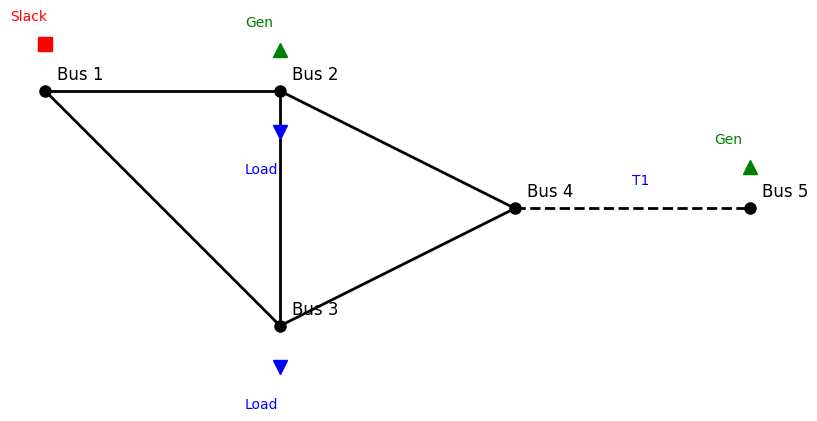

In [ ]:
fig, ax = gp.create_figure()
# bus positions
pos = {
    b1: (1.0, 4.0),
    b2: (3.0, 4.0),
    b3: (3.0, 1.8),
    b4: (5.8, 2.9),
    b5: (8.4, 2.9),
}

# draw buses
for b, (x, y) in pos.items():
    gp.bus(ax, x, y, net.bus.at[b, "name"])

# draw impedance branches
line_names = ["A", "B", "C", "D", "E"]
for i, row in net.impedance.iterrows():
    gp.line(ax, pos[row.from_bus], pos[row.to_bus], label=f"line {line_names[i]}")

# draw transformer
for _, row in net.trafo.iterrows():
    gp.trafo(ax, pos[row.hv_bus], pos[row.lv_bus], label="T1")

# draw external grid
for _, row in net.ext_grid.iterrows():
    x, y = pos[row.bus]
    gp.ext_grid(ax, x, y)

# draw generators
for i, row in net.gen.iterrows():
    x, y = pos[row.bus]
    gp.gen_up(ax, x, y, label=f"gen {i}")

# draw loads
for i, row in net.load.iterrows():
    x, y = pos[row.bus]
    gp.load_down(ax, x, y, label=f"load {i}")

# small black squares
gp.square(ax, 3.0, 3.45)
gp.square(ax, 3.0, 2.35)
gp.square(ax, 5.20, 2.65)
gp.square(ax, 6.40, 2.65)

# set limits and aspect
ax.set_xlim(0.3, 9.0)
ax.set_ylim(0.3, 5.4)
ax.set_aspect("equal")
ax.axis("off")

plt.show()




In [11]:
# run power flow
pp.runpp(net)

In [12]:
# extract results of voltages and loads from pandapower results
Vm = net.res_bus["vm_pu"].values
Va_deg = net.res_bus["va_degree"].values
S_base = net.sn_mva

Pload = np.zeros(len(net.bus))
Qload = np.zeros(len(net.bus))

for _, row in net.load.iterrows():
    Pload[row.bus] = row.p_mw
    Qload[row.bus] = row.q_mvar


print("Vm =", np.round(Vm, 3))
print("Va_deg =", np.round(Va_deg, 3))

Vm = [1.    1.05  0.951 1.014 1.   ]
Va_deg = [  0.      0.263 -14.298   4.685   7.512]


In [13]:
# compute power injections using Ybus formulas
P_inj_pu, Q_inj_pu = compute_power_injections(Ybus_manual, Vm, Va_deg)

P_inj_MW = P_inj_pu * S_base
Q_inj_Mvar = Q_inj_pu * S_base

inj_results = pd.DataFrame({
    "Bus": [1, 2, 3, 4, 5],
    "Vm (pu)": np.round(Vm, 3),
    "Va (deg)": np.round(Va_deg, 3),
    "P_inj (MW)": np.round(P_inj_MW, 2),
    "Q_inj (Mvar)": np.round(Q_inj_Mvar, 2)
})

print(inj_results.to_string(index=False))

 Bus  Vm (pu)  Va (deg)  P_inj (MW)  Q_inj (Mvar)
   1    1.000     0.000       54.69        -67.91
   2    1.050     0.263       50.00        -41.53
   3    0.951   -14.298     -200.00        -80.00
   4    1.014     4.685        0.00          0.00
   5    1.000     7.512      100.00        -25.18


In [14]:
# reconstruct generator powers

Pgen = P_inj_MW + Pload
Qgen = Q_inj_Mvar + Qload

gen_buses = np.array([True, True, False, False, True])

Pgen_display = np.where(gen_buses, np.round(Pgen, 2), np.nan)
Qgen_display = np.where(gen_buses, np.round(Qgen, 2), np.nan)

summary = pd.DataFrame({
    "Bus": [1, 2, 3, 4, 5],
    "|V| (pu)": np.round(Vm, 3),
    "Angle (deg)": np.round(Va_deg, 3),
    "Pgen (MW)": Pgen_display,
    "Qgen (Mvar)": Qgen_display,
    "Pload (MW)": Pload,
    "Qload (Mvar)": Qload
})

summary_display = summary.copy().astype(object)
summary_display = summary_display.where(pd.notnull(summary_display), "-")

print(summary_display.to_string(index=False))

Bus |V| (pu) Angle (deg) Pgen (MW) Qgen (Mvar) Pload (MW) Qload (Mvar)
  1      1.0         0.0     54.69      -67.91        0.0          0.0
  2     1.05       0.263     150.0      -21.53      100.0         20.0
  3    0.951     -14.298         -           -      200.0         80.0
  4    1.014       4.685         -           -        0.0          0.0
  5      1.0       7.512     100.0      -25.18        0.0          0.0


In [15]:
total_generation = np.nansum(Pgen_display)
total_load = np.sum(Pload)
total_active_loss = total_generation - total_load

print(f"Total generation = {total_generation:.2f} MW")
print(f"Total load       = {total_load:.2f} MW")
print(f"Total active loss = {total_active_loss:.2f} MW")

Total generation = 304.69 MW
Total load       = 300.00 MW
Total active loss = 4.69 MW


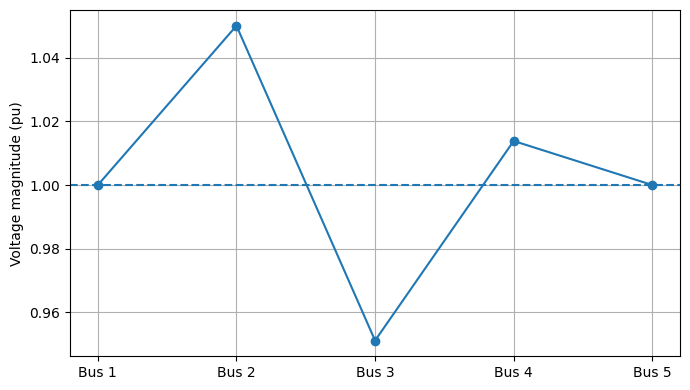

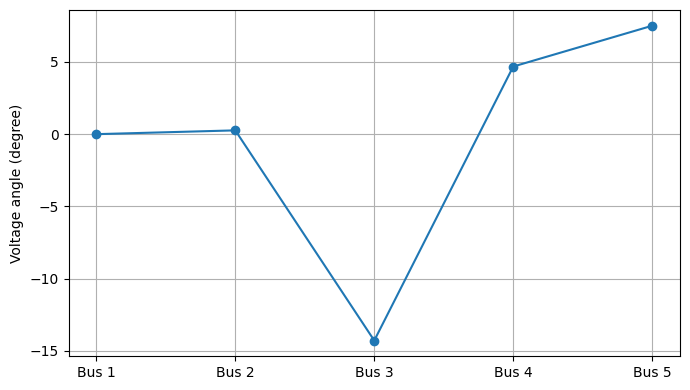

In [16]:
# Voltage magnitude plot
bus_names = net.bus["name"].tolist()
vm = net.res_bus["vm_pu"].tolist()

plt.figure(figsize=(7,4))
plt.plot(bus_names, vm, marker="o")
plt.axhline(1.0, linestyle="--")
plt.ylabel("Voltage magnitude (pu)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Voltage angle plot
angles = net.res_bus["va_degree"].tolist()

plt.figure(figsize=(7,4))
plt.plot(bus_names, angles, marker="o")
plt.ylabel("Voltage angle (degree)")
plt.grid(True)
plt.tight_layout()
plt.show()